# 大数定律与中心极限定理

学习目标：能区分样本均值的稳定性与抽样分布形状，在明确条件下使用标准误和正态近似，并通过重复抽样核对有限样本的表现。

前置知识：期望、方差、协方差、独立性、Bernoulli 与二项分布、正态分布、分布函数、NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11；仅生成小型教学数据。

环境准备：[数学基础运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 一组观测得到一个样本均值

记 $X_1,\ldots,X_n$ 为 n 次实值观测对应的随机变量，n 为正整数。样本均值定义为

$$\overline X_n=\frac1n\sum_{i=1}^nX_i.$$

抽样前，$\overline X_n$ 是随机变量；抽样后得到具体数值 $\overline x_n$。例如，每次试验成功记 1、失败记 0，下面 8 次观测得到的均值就是本组成功比例。它不等于“总体成功概率已被精确知道”。

In [1]:
from fractions import Fraction
from itertools import product
from math import ceil, floor

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

observed = np.array([0, 0, 1, 0, 0, 0, 1, 0])
print("样本量：", observed.size)  # 预期为 8。
print("本组样本均值：", observed.mean())  # 2/8 = 0.25，是本组的实际值。

样本量： 8
本组样本均值： 0.25


### 1.1 枚举样本均值的抽样分布

现在指定模型：每次 $X_i$ 独立地服从 Bernoulli 分布，成功概率 $p=1/4$。先只取 n=2。四个有序样本 $(0,0),(0,1),(1,0),(1,1)$ 的概率分别为 $9/16,3/16,3/16,1/16$，并不等概率。

它们对应的均值分别为 $0,1/2,1/2,1$。把相同均值的概率相加，得到均值的抽样分布（sampling distribution）：$P(\overline X_2=0)=9/16$、$P(\overline X_2=1/2)=3/8$、$P(\overline X_2=1)=1/16$。抽样分布描述重复取整组样本时，统计量可能得到什么值及其概率。

In [2]:
p_exact = Fraction(1, 4)
mean_probabilities = {}
for sample in product([0, 1], repeat=2):
    successes = sum(sample)
    probability = p_exact**successes * (1 - p_exact) ** (2 - successes)
    mean_value = Fraction(successes, 2)
    mean_probabilities[mean_value] = (
        mean_probabilities.get(mean_value, Fraction(0)) + probability
    )

for mean_value, probability in mean_probabilities.items():
    print("均值：", mean_value, "；概率：", probability)  # 均值 0、1/2、1 的概率依次为 9/16、3/8、1/16。
print("总概率：", sum(mean_probabilities.values()))  # 1。
# 单次观测只有 0、1；两次观测的均值还可能取 1/2。

均值： 0 ；概率： 9/16
均值： 1/2 ；概率： 3/8
均值： 1 ；概率： 1/16
总概率： 1


## 2 样本均值的方差与标准误

独立同分布（independent and identically distributed，i.i.d.）表示各次观测相互独立，并来自相同的概率分布。若共同均值为 $\mu=E[X_i]$，共同方差为 $\sigma^2=\operatorname{Var}(X_i)<\infty$，则

$$E[\overline X_n]=\frac1n\sum_{i=1}^n\mu=\mu,$$

$$\operatorname{Var}(\overline X_n)
=\frac1{n^2}\operatorname{Var}\!\left(\sum_{i=1}^nX_i\right)
=\frac{n\sigma^2}{n^2}=\frac{\sigma^2}{n}.$$

第二个等式利用独立性使不同观测之间的协方差为零。样本均值的标准差称为它的标准误（standard error，SE）：$\operatorname{SE}(\overline X_n)=\sigma/\sqrt n$。这些均值、方差公式在条件成立时对每个 n 都精确成立，不要求先用中心极限定理。

对 Bernoulli 模型，$\mu=p=1/4$、$\sigma^2=p(1-p)=3/16$，所以 n=2 时均值的方差为 $3/32$。下面直接用枚举出的分布核对。

In [3]:
mean_of_mean = sum(
    value * probability for value, probability in mean_probabilities.items()
)
variance_of_mean = sum(
    (value - mean_of_mean) ** 2 * probability
    for value, probability in mean_probabilities.items()
)
print("枚举得到的 E[样本均值]：", mean_of_mean)  # 1/4。
print("枚举得到的 Var[样本均值]：", variance_of_mean)  # 3/32。
print("公式给出的方差：", p_exact * (1 - p_exact) / 2)  # 预期为 3/32。
for n in [2, 8, 32]:
    # 样本量 2、8、32 的理论标准误依次约为 0.306186、0.153093、0.076547。
    print(f"n={n}，理论标准误={np.sqrt(float(p_exact * (1 - p_exact)) / n):.6f}")
# n 每增加到原来的 4 倍，标准误才减半。

枚举得到的 E[样本均值]： 1/4
枚举得到的 Var[样本均值]： 3/32
公式给出的方差： 3/32
n=2，理论标准误=0.306186
n=8，理论标准误=0.153093
n=32，理论标准误=0.076547


### 2.1 标准差与标准误估计不能混用

总体标准差 $\sigma$ 描述一次观测的波动，$\sigma/\sqrt n$ 描述整组样本均值的波动。若 $\sigma$ 未知，常用样本标准差

$$s=\sqrt{\frac1{n-1}\sum_{i=1}^n(x_i-\overline x_n)^2},\qquad n\ge2,$$

得到标准误估计 $\widehat{\operatorname{SE}}=s/\sqrt n$。估计值随样本改变，不必恰好等于理论标准误，也不是本次均值误差的绝对上界。这里使用独立同分布模型；有依赖的数据不能机械套用此式。

NumPy 的 std 默认分母为 n，使用 ddof=1 才得到上述样本标准差；SciPy 的 sem 默认使用 ddof=1。

In [4]:
sample_sd = observed.std(ddof=1)
estimated_se = sample_sd / np.sqrt(observed.size)
theoretical_se = np.sqrt(float(p_exact * (1 - p_exact)) / observed.size)
print("样本标准差：", sample_sd)  # 预期约为 0.46291。
print("估计标准误、理论标准误：", estimated_se, theoretical_se)  # 预期约为 0.163663 0.153093。
# 预期为 True。
print(
    "与 SciPy sem 一致：",
    np.isclose(estimated_se, stats.sem(observed), atol=1e-14, rtol=0),
)
# 约为 0.46291、0.16366、0.15309；s 与 s/√n 回答不同问题。

样本标准差： 0.4629100498862757
估计标准误、理论标准误： 0.16366341767699427 0.15309310892394862
与 SciPy sem 一致： True


## 3 大数定律说明均值会靠近什么

本章引用的 i.i.d. 大数定律版本要求 $E[|X_1|]<\infty$，即随机变量可积，令 $\mu=E[X_1]$。弱大数定律（weak law of large numbers）给出

$$P\!\left(|\overline X_n-\mu|\ge\varepsilon\right)\longrightarrow0
\quad(n\to\infty),\qquad \text{对每个固定 }\varepsilon>0.$$

$\varepsilon$ 是允许的误差阈值。结论说“超过固定误差的概率趋于零”，不说每一步误差都下降，也不为有限样本保证误差一定小于阈值。这个版本只需可积，不要求方差有限。

若进一步有有限方差，可以给出一个简短证明。因为误差超过 $\varepsilon$ 时，$(\overline X_n-\mu)^2/\varepsilon^2\ge1$，对这一不等式取期望可得 Chebyshev 界：

$$P\!\left(|\overline X_n-\mu|\ge\varepsilon\right)
\le\frac{E[(\overline X_n-\mu)^2]}{\varepsilon^2}
=\frac{\sigma^2}{n\varepsilon^2}\longrightarrow0.$$

这是有限方差情形的推导，不是对只有有限一阶矩情形的证明。对 $p=1/4$ 的 Bernoulli 样本，取 $\varepsilon=1/8$，还可用二项分布直接算出左边，与上界比较。

In [5]:
p = float(p_exact)
epsilon = 1 / 8
for n in [20, 100, 400]:
    counts = np.arange(n + 1)
    # |k/n - 1/4| >= 1/8 等价于 |8k - 2n| >= n，避免端点浮点比较。
    outside = np.abs(8 * counts - 2 * n) >= n
    exact_probability = stats.binom.pmf(counts[outside], n, p).sum()
    bound = min(1.0, p * (1 - p) / (n * epsilon**2))
    # 精确超差概率约从 0.193072 降至 2e-8；三组都低于各自上界 0.6、0.12、0.03。
    print(f"n={n}，精确超差概率={exact_probability:.8f}，Chebyshev 上界={bound:.6f}")
# 精确概率不超过上界；上界可能很宽松，它不是近似等式。

n=20，精确超差概率=0.19307229，Chebyshev 上界=0.600000
n=100，精确超差概率=0.00377358，Chebyshev 上界=0.120000
n=400，精确超差概率=0.00000002，Chebyshev 上界=0.030000


## 4 三种收敛说的是不同事情

下面用 $Y_n$ 表示随机变量序列，Y 表示极限随机变量，$F_{Y_n}(t)=P(Y_n\le t)$ 是其分布函数，t 是实数阈值。需要比较同一条样本路径时，把这些随机变量定义在同一个概率空间上。

| 名称 | 中文含义与数学表达 |
| --- | --- |
| Convergence in probability | 依概率收敛：对每个 $\varepsilon>0$，$P(\lvert Y_n-Y\rvert\ge\varepsilon)\to0$，记作 $Y_n\xrightarrow{P}Y$。 |
| Almost sure convergence | 几乎处处收敛：$P(\lim_{n\to\infty}Y_n=Y)=1$，记作 $Y_n\xrightarrow{a.s.}Y$；除一个零概率集合外，每条无限样本路径都收敛。 |
| Convergence in distribution | 依分布收敛：在 $F_Y$ 的每个连续点 t，$F_{Y_n}(t)\to F_Y(t)$，记作 $Y_n\xrightarrow{d}Y$；比较的是分布，不是每条路径的数值。 |

几乎处处收敛推出依概率收敛，依概率收敛推出依分布收敛，逆向一般不成立。在 i.i.d. 且 $E[|X_1|]<\infty$ 的条件下，强大数定律（strong law of large numbers）还给出 $\overline X_n\xrightarrow{a.s.}\mu$；这里引用结论，不展开证明。

用一个简单例子看出“分布不变”与“路径收敛”的区别：Y 以各 1/2 的概率取 −1、1，令 $Y_n=(-1)^nY$。每个 $Y_n$ 都与 Y 同分布，但每条路径在 −1、1 之间往返，不会收敛。有限代码只展示该代数构造的前几项。

In [6]:
indices = np.arange(1, 9)
possible_y = np.array([-1, 1])
paths = possible_y[:, None] * (-1) ** indices
print("两条可能路径的前 8 项：\n", paths)  # 预期为 [[ 1 -1 1 -1 1 -1 1 -1] [-1 1 -1 1 -1 1 -1 1]]。
print("每列 P(Y_n <= 0)：", (paths <= 0).mean(axis=0))  # 预期约为 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]。
# 每列分布都相同，但两条路径都持续交替；分布收敛不等于路径收敛。

两条可能路径的前 8 项：
 [[ 1 -1  1 -1  1 -1  1 -1]
 [-1  1 -1  1 -1  1 -1  1]]
每列 P(Y_n <= 0)： [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


## 5 观察一条累计均值轨迹

用指数分布构造等待时长，单位为秒。指定均值尺度 $\theta=2\,\mathrm{s}$，密度为 $f(x)=e^{-x/\theta}/\theta$（$x\ge0$），对应速率 $1/\theta=0.5\,\mathrm{s}^{-1}$。它的均值 $\mu=2\,\mathrm{s}$，标准差 $\sigma=2\,\mathrm{s}$；各次等待时长假定 i.i.d.。

种子固定为 1801，生成 3 组各 5000 次观测，分别计算前 n 次的累计均值。每一条曲线都是一条有限样本路径，不是样本均值的概率密度。观察均值靠近 2 的同时，也应保留局部回升和回落。

模型均值与方差： 2.0 4.0
三条路径末端的均值 (s)： [1.94610139 1.99937089 2.06277431]
三条路径末端的误差 (s)： [-0.05389861 -0.00062911  0.06277431]


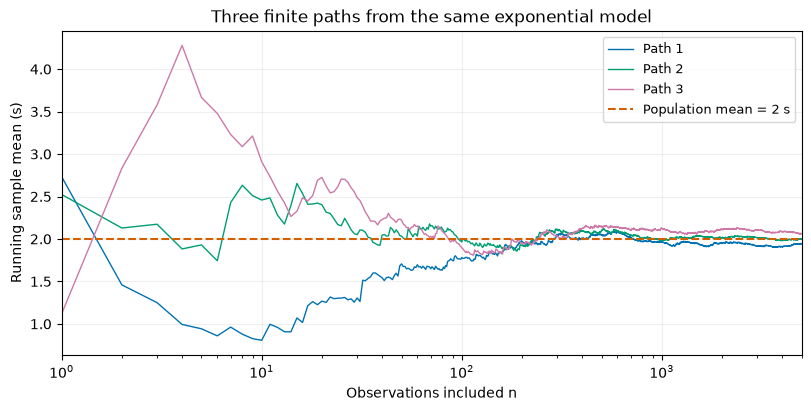

In [7]:
scale = 2.0
mu, variance = stats.expon.stats(scale=scale, moments="mv")
sigma = np.sqrt(variance)
path_rng = np.random.default_rng(1801)
path_count = 3
path_length = 5000
# 三行分别是三条独立模拟路径，沿列累计后除以当前观测数。
waits = path_rng.exponential(scale=scale, size=(path_count, path_length))
sample_counts = np.arange(1, path_length + 1)
running_means = np.cumsum(waits, axis=1) / sample_counts
print("模型均值与方差：", mu, variance)  # 2 秒、4 平方秒。
print("三条路径末端的均值 (s)：", running_means[:, -1])  # 本次固定种子下约为 [1.9461 1.99937 2.06277]。
print("三条路径末端的误差 (s)：", running_means[:, -1] - mu)  # 本次固定种子下约为 [-0.0538986 -0.00062911 0.0627743]。

# 每条路径画一条累计均值曲线，水平线始终是同一个总体均值。
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for index, color in enumerate(["#0072B2", "#009E73", "#CC79A7"]):
    ax.plot(
        sample_counts,
        running_means[index],
        color=color,
        linewidth=1,
        label=f"Path {index + 1}",
    )
ax.axhline(mu, color="#D55E00", linestyle="--", label="Population mean = 2 s")
ax.set(
    xscale="log",
    xlabel="Observations included n",
    ylabel="Running sample mean (s)",
    title="Three finite paths from the same exponential model",
    xlim=(1, path_length),
)
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
# 本次三条累计均值后段靠近 2 s 虚线但仍有波动，末值约 1.946、1.999、2.063 s。
plt.show()

## 6 中心极限定理研究标准化后的波动

经典 i.i.d. 中心极限定理（central limit theorem，CLT）要求 $E[X_i]=\mu$ 和 $0<\operatorname{Var}(X_i)=\sigma^2<\infty$。定义

$$Z_n=\frac{\overline X_n-\mu}{\sigma/\sqrt n}
=\frac{\sum_{i=1}^nX_i-n\mu}{\sigma\sqrt n}.$$

定理给出 $Z_n\xrightarrow{d}N(0,1)$，即对每个实数 z，$P(Z_n\le z)\to\Phi(z)$，其中 $\Phi$ 是标准正态分布函数。这里引用定理，不用有限模拟代替证明。若 $\sigma^2=0$，观测几乎必然等于均值，上述标准化会除以零，不属于这个版本。

大数定律说未放大的误差趋近 0；CLT 把误差除以缩小的标准误，描述放大后的分布形状，两者并不矛盾。它不说原始 $X_i$ 的分布会变成正态，也不说一条 $Z_n$ 轨迹会收敛到某个固定的“正态数值”。

在上述条件下，$E[Z_n]=0$、$\operatorname{Var}(Z_n)=1$ 对每个 n 都成立，但这两点本身不足以推出正态性。仍用 n=2、p=1/4 的精确分布核对。

In [8]:
mean_values = np.array([float(value) for value in mean_probabilities])
probabilities = np.array([float(value) for value in mean_probabilities.values()])
se_two = np.sqrt(p * (1 - p) / 2)
z_two = (mean_values - p) / se_two
print("标准化后的三个可能值：", z_two)  # 预期约为 [-0.816497 0.816497 2.44949]。
print("精确分布计算的均值与方差：", probabilities @ z_two, probabilities @ z_two**2)  # 预期均值接近 0、方差接近 1；本次均值约 -2.8e-17，是舍入量级。
# 预期约为 0.5625 ；标准正态： 0.5。
print(
    "P(Z_2 <= 0)：", probabilities[z_two <= 0].sum(), "；标准正态：", stats.norm.cdf(0)
)
# 均值接近 0、方差接近 1，但仍是三个离散取值；0.5625 不等于 0.5。

标准化后的三个可能值： [-0.81649658  0.81649658  2.44948974]
精确分布计算的均值与方差： -2.7755575615628914e-17 1.0000000000000002
P(Z_2 <= 0)： 0.5625 ；标准正态： 0.5


## 7 重复抽样才能观察均值的分布

对指数模型分别取 n=1、10、100，每个 n 重新生成 R=6000 组独立样本，组内仍为 i.i.d.，种子固定为 1802。这里有两个数量：一组有 n 个观测，一共重复 R 组。

![样本数组每行含 n 个观测，共 R 行；沿每行求均值得到 R 个均值，用这些均值观察抽样分布。](image/illustration/18-01-repeated-sampling.svg)

图中 $x_{rj}$ 表示第 r 组第 j 个观测，$\bar x_r$ 表示该组均值，$r=1,\ldots,R$、$j=1,\ldots,n$。省略号压缩了数组规模，并非实际生成的完整样本。

n 改变每个均值的真实抽样分布；R 改变我们用多少次重复观察该分布，影响模拟图表的稳定程度。固定 n 时，增大 R 不会使该均值分布本身更接近正态。

下面沿图中的行方向计算均值，再比较这 R 个均值的平均值、标准差与均方根误差。均方根误差为 $\sqrt{R^{-1}\sum_{r=1}^{R}(\overline x_n^{(r)}-\mu)^2}$；它使用已知模型均值，理论值为 $\sigma/\sqrt n$。后面的直方图应统计每行均值，而不是把全部原始观测混在一起。

In [9]:
distribution_rng = np.random.default_rng(1802)
repetitions = 6000
sample_sizes = [1, 10, 100]
sample_means = {}
standardized_means = {}
for n in sample_sizes:
    samples = distribution_rng.exponential(scale=scale, size=(repetitions, n))
    means = samples.mean(axis=1)
    se = sigma / np.sqrt(n)
    sample_means[n] = means
    standardized_means[n] = (means - mu) / se
    rmse = np.sqrt(np.mean((means - mu) ** 2))
    # 本次各组均值约 2 s；模拟 SD 约 1.973、0.648、0.204 s，对照理论 SE 2、0.632、0.2 s。
    print(
        f"n={n:3d}：均值的平均={means.mean():.5f} s，均值的样本标准差={means.std(ddof=1):.5f} s，RMSE={rmse:.5f} s，理论SE={se:.5f} s"
    )
# 平均位置在 2 秒附近；跨组均值的标准差与 RMSE 都应接近 2/√n。

n=  1：均值的平均=1.99645 s，均值的样本标准差=1.97275 s，RMSE=1.97259 s，理论SE=2.00000 s
n= 10：均值的平均=1.99896 s，均值的样本标准差=0.64793 s，RMSE=0.64788 s，理论SE=0.63246 s
n=100：均值的平均=2.00099 s，均值的样本标准差=0.20367 s，RMSE=0.20366 s，理论SE=0.20000 s


下图使用 $Z_n$ 作横轴，三个面板的坐标范围相同。n=1 的面板就是单次指数观测经平移缩放后的分布，仍明显右偏；另外两个面板对应 10 次、100 次观测的均值。橙线是标准正态密度。

直方图使用 density=True，使所有柱子的总面积为 1，柱高不是落入某一箱的概率。有限 R 的直方图仍有抽样波动，形状贴合也不能保证某个很小尾部概率具有足够的相对精度。

n=1：直方图面积=1.000000000000，图外样本数=0

n=10：直方图面积=1.000000000000，图外样本数=0
n=100：直方图面积=1.000000000000，图外样本数=0


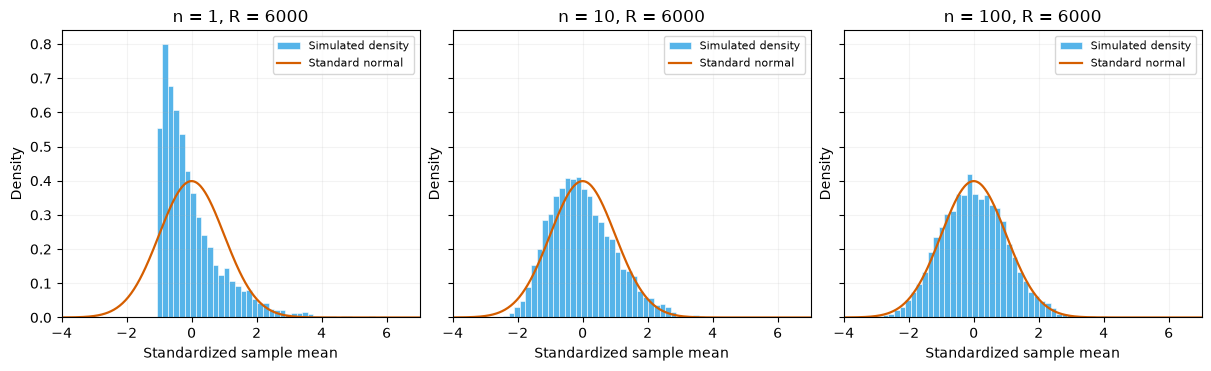

In [10]:
# 三幅图共用分箱与坐标范围，避免各自缩放造成形状比较偏差。
plot_max = max(5.0, max(values.max() for values in standardized_means.values()) + 0.2)
bin_edges = np.linspace(-4, plot_max, 65)
z_grid = np.linspace(-4, plot_max, 500)
fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.6), sharex=True, sharey=True, layout="constrained"
)
for ax, n in zip(axes, sample_sizes):
    # 每个元素是一次独立实验的标准化均值，不是原始指数分布样本。
    values = standardized_means[n]
    heights, edges, _ = ax.hist(
        values,
        bins=bin_edges,
        density=True,
        color="#56B4E9",
        edgecolor="white",
        linewidth=0.4,
        label="Simulated density",
    )
    # 叠加标准正态密度作近似对照；有限重复实验仍会有波动。
    ax.plot(
        z_grid,
        stats.norm.pdf(z_grid),
        color="#D55E00",
        linewidth=1.6,
        label="Standard normal",
    )
    ax.set(
        title=f"n = {n}, R = {repetitions}",
        xlabel="Standardized sample mean",
        ylabel="Density",
        xlim=(-4, plot_max),
    )
    ax.grid(alpha=0.15)
    ax.legend(fontsize=8)
    # 本次三幅直方图面积均约为 1，图外样本数都为 0。
    print(
        f"n={n}：直方图面积={np.sum(heights * np.diff(edges)):.12f}，图外样本数={np.count_nonzero((values < bin_edges[0]) | (values > bin_edges[-1]))}"
    )
# 本次 n=1 的标准化均值明显右偏；n=10、100 时更接近叠加的标准正态密度。
plt.show()

再选定几个实数阈值 z，比较 $R^{-1}\sum_{r=1}^R\mathbf1\{Z_n^{(r)}\le z\}$ 与 $\Phi(z)$。其中指示符 $\mathbf1\{\cdot\}$ 在条件成立时为 1，否则为 0。这个表比只看曲线更明确地对应 CLT 的分布函数结论。

有限样本量下，近似偏差与 R 次模拟自身的随机误差会混在一起；不能把某个阈值上的偏差当作全分布误差上界。

In [11]:
thresholds = np.array([-1.0, 0.0, 1.0, 2.0])
normal_cdf = stats.norm.cdf(thresholds)
print("阈值：", thresholds)  # 预期为给定阈值 [-1, 0, 1, 2]。
print("标准正态 CDF：", np.round(normal_cdf, 4))  # 标准正态的理论 CDF 约为 [0.1587, 0.5, 0.8413, 0.9772]。
for n in sample_sizes:
    empirical_cdf = (standardized_means[n][:, None] <= thresholds).mean(axis=0)
    # 本次 n=100 的 CDF 约为 [0.1675, 0.5093, 0.8412, 0.9692]，仍与标准正态有有限样本差异。
    print(
        f"n={n:3d}：模拟CDF={np.round(empirical_cdf, 4)}，差值={np.round(empirical_cdf - normal_cdf, 4)}"
    )
# n 增加后通常更接近标准正态，但不要求每格模拟误差都单调下降。

阈值： [-1.  0.  1.  2.]
标准正态 CDF： [0.1587 0.5    0.8413 0.9772]
n=  1：模拟CDF=[0.     0.6357 0.8592 0.952 ]，差值=[-0.1587  0.1357  0.0178 -0.0252]
n= 10：模拟CDF=[0.1613 0.5445 0.8383 0.9602]，差值=[ 0.0027  0.0445 -0.003  -0.0171]
n=100：模拟CDF=[0.1675 0.5093 0.8412 0.9692]，差值=[ 0.0088  0.0093 -0.0002 -0.0081]


## 8 综合应用：成功比例的误差概率

假定每次请求独立成功，成功概率固定为 $p=1/5$，令 $X_i$ 为成功指示变量。成功总数 $K_n=\sum_{i=1}^{n}X_i\sim\operatorname{Binomial}(n,p)$，样本成功比例为 $\widehat p=K_n/n$。这是人为指定的试验模型，不是实际服务监测记录。

希望计算 $P(|\widehat p-p|\le\delta)$，其中容许误差 $\delta=1/20$。精确事件必须先转换为整数计数：

$$L=\lceil n(p-\delta)\rceil,\qquad U=\lfloor n(p+\delta)\rfloor,\qquad L\le K_n\le U.$$

本例的 L、U 都落在 0 到 n 内。上取整、下取整分别记为 $\lceil\cdot\rceil$、$\lfloor\cdot\rfloor$。精确概率来自二项分布；未经连续性修正的正态近似是 $\Phi(\delta/\mathrm{SE})-\Phi(-\delta/\mathrm{SE})$，其中 $\mathrm{SE}=\sqrt{p(1-p)/n}$。

二项计数是离散的。用连续正态分布近似整数区间时，可将端点扩展到 $[L-1/2,U+1/2]$，称为连续性修正（continuity correction）：

$$P(L\le K_n\le U)\approx
\Phi\!\left(\frac{U+1/2-np}{\sqrt{np(1-p)}}\right)
-\Phi\!\left(\frac{L-1/2-np}{\sqrt{np(1-p)}}\right).$$

下面使用精确分数计算整数端点，避免小浮点误差把本应为整数的端点取整到相邻数。

In [12]:
success_probability = Fraction(1, 5)
allowed_error = Fraction(1, 20)
comparison_rows = []
for n in [40, 160, 640]:
    # 先将比例误差限制转成整数计数区间，端点分别向上、向下取整。
    low = ceil(n * (success_probability - allowed_error))
    high = floor(n * (success_probability + allowed_error))
    p_model = float(success_probability)
    # CDF 的差覆盖 low 到 high，因此下端要减去 low-1 的累计概率。
    exact = stats.binom.cdf(high, n, p_model) - stats.binom.cdf(low - 1, n, p_model)
    se = np.sqrt(p_model * (1 - p_model) / n)
    normal = stats.norm.cdf(float(allowed_error) / se) - stats.norm.cdf(
        -float(allowed_error) / se
    )
    # 连续性修正在计数尺度将左右端点各扩展半个单位。
    count_sd = np.sqrt(n * p_model * (1 - p_model))
    corrected = stats.norm.cdf((high + 0.5 - n * p_model) / count_sd) - stats.norm.cdf(
        (low - 0.5 - n * p_model) / count_sd
    )
    comparison_rows.append((n, low, high, exact, normal, corrected))
    # 三组精确概率约 0.677902、0.907916、0.998671；连续性修正值约 0.676951、0.907035、0.998680。
    print(
        f"n={n}，计数区间=[{low},{high}]，SE={se:.6f}，精确={exact:.6f}，正态={normal:.6f}，修正={corrected:.6f}"
    )
    # 三组修正后误差约 -0.000951、-0.000881、0.000009，本例均小于未修正误差。
    print(f"  两种近似的误差：{normal - exact:+.6f}，{corrected - exact:+.6f}")
# 正态近似不等于精确概率；连续性修正照顾整数边界，但也不是普遍的精度保证。

n=40，计数区间=[6,10]，SE=0.063246，精确=0.677902，正态=0.570805，修正=0.676951
  两种近似的误差：-0.107097，-0.000951
n=160，计数区间=[24,40]，SE=0.031623，精确=0.907916，正态=0.886154，修正=0.907035
  两种近似的误差：-0.021762，-0.000881
n=640，计数区间=[96,160]，SE=0.015811，精确=0.998671，正态=0.998435，修正=0.998680
  两种近似的误差：-0.000237，+0.000009


对每个 n 再做 R=12000 组独立重复，种子固定为 1803。这里直接生成每组的二项成功总数，等价于对该组 n 个独立 Bernoulli 变量求和；每个生成值代表一整组试验。

模拟频率与二项精确概率对照，正态近似也与同一个精确概率对照。模拟结果并不是用来定义“正确答案”的另一条近似公式。

In [13]:
comparison_rng = np.random.default_rng(1803)
comparison_repetitions = 12_000
for n, low, high, exact, normal, corrected in comparison_rows:
    success_counts = comparison_rng.binomial(
        n, float(success_probability), size=comparison_repetitions
    )
    inside = (success_counts >= low) & (success_counts <= high)
    frequency = inside.mean()
    empirical_se = (success_counts / n).std(ddof=1)
    # 本次频率约 0.674167、0.904167、0.998583，分别与前面的精确概率比较；误差有单次模拟波动。
    print(
        f"n={n}：区间内组数={inside.sum()}/{comparison_repetitions}，频率={frequency:.6f}，精确概率={exact:.6f}，频率误差={frequency - exact:+.6f}，均值的样本标准差={empirical_se:.6f}"
    )
# 更大的 n 改变区间覆盖概率和均值的标准误；R 只控制此处模拟统计的波动。

n=40：区间内组数=8090/12000，频率=0.674167，精确概率=0.677902，频率误差=-0.003735，均值的样本标准差=0.063223
n=160：区间内组数=10850/12000，频率=0.904167，精确概率=0.907916，频率误差=-0.003749，均值的样本标准差=0.031705
n=640：区间内组数=11983/12000，频率=0.998583，精确概率=0.998671，频率误差=-0.000088，均值的样本标准差=0.015773


## 9 正态近似与定理条件的边界

### 9.1 样本量没有统一的合格门槛

“n 达到 30 就足够”不是经典 CLT 的结论。有限样本近似还取决于原分布的偏斜程度及所关心的区间。对罕见事件，即便 n=100，成功总数仍可能集中在很少几个整数上。

令 $p=0.005$、n=100，此时 $np=0.5$。精确的零成功概率是 $(1-p)^n$。下面将它与近似 $P(K_n\le0)$ 的连续性修正结果比较，并检查未经截断的正态近似分配了多少概率给不可能的负计数。这是有限样本近似不足，不能据此否定在固定 p 下、n 趋于无穷的 CLT。

In [14]:
rare_p = 0.005
rare_n = 100
count_mean = rare_n * rare_p
count_sd = np.sqrt(rare_n * rare_p * (1 - rare_p))
exact_zero = stats.binom.pmf(0, rare_n, rare_p)
normal_zero = stats.norm.cdf((0.5 - count_mean) / count_sd)
impossible_negative = stats.norm.cdf((0 - count_mean) / count_sd)
print("零成功：精确、正态连续性修正：", exact_zero, normal_zero)  # 预期约为 0.60577 0.5。
print("正态近似落在负计数区间的概率：", impossible_negative)  # 预期约为 0.239199。
# 约为 0.60577 对 0.5；约 0.239 的概率落在负数，提示本例近似形状不合适。

零成功：精确、正态连续性修正： 0.6057704364907283 0.5
正态近似落在负计数区间的概率： 0.23919909972446773


### 9.2 重尾要分别检查一阶矩和二阶矩

“重尾”本身不等于定理失效；本章版本要检查相应矩条件。以支持集 $x\ge1$ 的 Pareto 分布为例，密度 $f(x)=\alpha x^{-\alpha-1}$，形状参数 $\alpha>0$。对正数 r，

$$E[X^r]=\alpha\int_1^\infty x^{r-\alpha-1}\,dx$$

当 $r<\alpha$ 时等于 $\alpha/(\alpha-r)$，当 $r\ge\alpha$ 时发散。因此 $\alpha=1.5$ 时 $E[|X|]=3$，而 $E[X^2]=\infty$。i.i.d. 样本均值仍适用可积版本的大数定律，却不满足本章经典有限方差 CLT 的条件；$\sigma/\sqrt n$ 也不再是一个有限标准误。

这不意味着所有可能的极限定理都失效，只说明不能直接使用这里的正态标准化。下面核对模型的矩，并计算逐渐扩大积分上限 M 时的截断二阶矩 $3(\sqrt M-1)$，M 为不小于 1 的实数。

In [15]:
pareto_mean, pareto_variance = stats.pareto.stats(1.5, moments="mv")
print("Pareto(1.5) 的均值与方差：", pareto_mean, pareto_variance)  # 3、inf。
for upper in [10, 100, 10_000]:
    truncated_second_moment = 3 * (np.sqrt(upper) - 1)
    print(f"M={upper}，截断二阶矩={truncated_second_moment:.6f}")  # 截断二阶矩依次约为 6.48683、27、297，随上限增大继续增长。
# 这些数值展示公式的增长；二阶矩发散由上面的积分判据说明。

Pareto(1.5) 的均值与方差： 3.0 inf
M=10，截断二阶矩=6.486833
M=100，截断二阶矩=27.000000
M=10000，截断二阶矩=297.000000


标准 Cauchy 分布的情形更强：其密度为 $1/[\pi(1+x^2)]$，支持集为整个实数轴。因为

$$\int_{-M}^{M}|x|\frac{dx}{\pi(1+x^2)}=\frac{\log(1+M^2)}\pi\longrightarrow\infty,$$

它没有有限均值，位置参数 0 不能被称为期望为 0。i.i.d. 标准 Cauchy 变量的样本均值仍服从同一个标准 Cauchy 分布；这是该分布的性质，说明 $P(|\overline X_n|\le1)=1/2$ 对所有 n 都一样，不会随 n 集中到 0。

不能用对称正负数相消来补出一个不存在的均值，也不能把有限样本方差始终能算出一个数误当作总体方差有限。

In [16]:
print("Cauchy 模型的均值、方差接口结果：", stats.cauchy.stats(moments="mv"))  # 预期为 (nan, nan)。
# 预期约为 0.5。
print(
    "样本均值落在 [-1,1] 的概率（任意 n）：", stats.cauchy.cdf(1) - stats.cauchy.cdf(-1)
)
# nan 表示这里没有定义的有限均值/方差；概率为 0.5，不依赖样本量。

Cauchy 模型的均值、方差接口结果： (np.float64(nan), np.float64(nan))
样本均值落在 [-1,1] 的概率（任意 n）： 0.5


### 9.3 重复同一个观测不产生独立信息

令 Y 以各 1/2 的概率取 −1、1，然后定义所有 $X_i=Y$。各 $X_i$ 都有均值 0、方差 1，也同分布，但完全依赖。无论 n 多大，$\overline X_n=Y$，所以 $P(|\overline X_n|>1/2)=1$，均值不向 0 集中。

一般地，在有限方差下，

$$\operatorname{Var}(\overline X_n)=\frac1{n^2}
\left(\sum_{i=1}^n\operatorname{Var}(X_i)+2\sum_{i<j}\operatorname{Cov}(X_i,X_j)\right).$$

本例每个协方差都是 1，分子为 $n+n(n-1)=n^2$，故方差仍为 1。存在适用于某些依赖序列的大数定律与 CLT，但需要另外的条件，不能从相同的边缘分布直接推出。

In [17]:
dependence_rng = np.random.default_rng(1804)
dependence_repetitions = 4000
shared_values = dependence_rng.choice([-1.0, 1.0], size=dependence_repetitions)
for n in [1, 10, 100]:
    dependent_samples = np.repeat(shared_values[:, None], n, axis=1)
    dependent_means = dependent_samples.mean(axis=1)
    # 本次三组 SD 均约 1.000107，超差比例均为 1；没有按独立公式 1/√n 缩小。
    print(
        f"n={n}：跨组均值的样本标准差={dependent_means.std(ddof=1):.6f}，错误套用的1/√n={1 / np.sqrt(n):.6f}，误差超过0.5的组比例={np.mean(np.abs(dependent_means) > 0.5):.1f}"
    )
# 每组只随机选择一次 Y，再复制 n 次；标准差保持约 1，超差比例恒为 1。

n=1：跨组均值的样本标准差=1.000107，错误套用的1/√n=1.000000，误差超过0.5的组比例=1.0
n=10：跨组均值的样本标准差=1.000107，错误套用的1/√n=0.316228，误差超过0.5的组比例=1.0
n=100：跨组均值的样本标准差=1.000107，错误套用的1/√n=0.100000，误差超过0.5的组比例=1.0


## 本章小结

（1）样本均值的抽样分布描述重复抽取整组样本时均值的分布，区别于原始单次观测分布。一组样本只给出一个均值。

（2）i.i.d. 且可积时，大数定律使样本均值趋近总体均值；有限方差进一步给出 $\operatorname{Var}(\overline X_n)=\sigma^2/n$ 及 Chebyshev 界。

（3）经典 i.i.d. CLT 还要求有限且非零的方差，描述标准化样本均值的依分布收敛。依概率、几乎处处、依分布收敛不能混作同一句话。

（4）标准误是统计量的标准差，$s/\sqrt n$ 是模型条件下的估计。样本量 n 与模拟重复次数 R 分工不同，增加 R 不会修复小 n 的正态近似偏差。

（5）偏斜、尾部、离散端点及依赖结构都影响结论的使用方式。模拟展示有限样本行为，定理及其条件给出数学结论。

自查：为什么指数观测始终右偏而均值的标准化分布可接近正态？为什么可积但方差无限时仍可能适用大数定律？为什么复制已有数据不会自动把标准误减小？

## 练习

（1）把 Bernoulli 精确枚举扩展到 n=3、p=1/4。列出所有有序样本及其概率，合并相同均值，核对总概率为 1、均值为 p、方差为 p(1−p)/3。再标准化，说明“均值为 0、方差为 1”为什么仍不能证明正态性。

In [18]:
exercise_p = Fraction(1, 4)
exercise_n = 3
# 使用 product 枚举；保留 Fraction 计算，最后再转成浮点数作标准化。

（2）在均值尺度为 2 秒的指数模型中，比较 n=4、16、64；每个 n 做 4000 组独立重复，固定种子。报告均值的样本标准差、RMSE、理论标准误，再将重复次数改为 8000。分清 n 增大和 R 增大的作用，并说明模拟中的标准差比值为何不必精确等于 2。

In [19]:
exercise_rng = np.random.default_rng(1805)
exercise_sizes = [4, 16, 64]
exercise_repetitions = [4000, 8000]
# 每个组合重新抽样；对理论 2/√n 做数值对照，不把模拟偏差称为证明。

（3）保持罕见事件概率 p=0.005，比较 n=100 与 n=1000 时零成功概率的精确值和带连续性修正的正态近似。报告绝对误差与相对误差（除以精确概率），解释为什么“直方图主体看起来更像正态”并不保证小尾部概率的相对误差也很小。

In [20]:
exercise_rare_p = 0.005
# 对每个 n 计算 binom.pmf(0, n, p)，并近似事件 K_n <= 0；明确修正端点。

（4）每组先独立生成 10 个均值为 0、方差为 1 的正态观测，再把每个观测复制 10 次，形成长度为 100 的数组。重复 3000 组并比较复制前后均值。推导实际标准误应该是 $1/\sqrt{10}$ 还是 $1/\sqrt{100}$，用跨组均值的样本标准差核对，并指出错误计算违反了哪个条件。

In [21]:
exercise_dependence_rng = np.random.default_rng(1806)
exercise_groups = 3000
# 先生成 (3000, 10) 的独立观测，再沿每行重复；不要把重复值当作新观测。

## 练习提示与解析

以下对应练习（4）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先把复制后的 100 项均值写成原来 10 项的和。

提示 2：方差公式中的独立观测数没有随着复制增加。

### 练习（4）参考解析

设原观测为 $X_1,\ldots,X_{10}$，复制后均值为 $\frac1{100}\sum_{i=1}^{10}10X_i=\frac1{10}\sum_{i=1}^{10}X_i$，与原均值逐组相同。

由原观测独立且方差为 1，均值方差是 $10/10^2=1/10$，标准误为 $1/\sqrt{10}\approx0.3162$。错误的 0.1 把同一对象的副本当成了独立观测。3000 组均值的样本标准差应在随机误差内接近 0.3162，不必精确相等；复制前后每组均值的相等则是代数恒等关系。

## 参考与引用来源

本章新增示意图由 CMYK Labs 原创，依据下表对应概念与本章教学输入绘制；示意图不作为实际运行截图或数学证明。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | 18.655 Spring 2016，[Lecture 15: Limit Theorems](https://ocw.mit.edu/courses/18-655-mathematical-statistics-spring-2016/6c41b4096a836ff41f8de46cf54b5b7c_MIT18_655S16_LecNote15.pdf)，第 3–4 页、17 页，可积 i.i.d. 弱大数定律；第 8–9 页，连续性修正与有限正方差 CLT；第 14 页，Cauchy 样本均值仍同分布。Scott Sheffield，18.175 Spring 2014，[Lecture 9](https://ocw.mit.edu/courses/18-175-theory-of-probability-spring-2014/4e8a2305c745bd5a82a5f15cf8bcb8bb_MIT18_175S14_Lecture9.pdf)，第 9–11 页，可积 i.i.d. 强大数定律。6.436J Fall 2018，[Lecture 16: Convergence of Random Variables](https://ocw.mit.edu/courses/6-436j-fundamentals-of-probability-fall-2018/b4ebf022b1060fcce920227d934dd6f0_MIT6_436JF18_lec16.pdf)，§1、§3，三种收敛定义、关系与依分布收敛不要求路径收敛。RES.6-012 Spring 2018，[Lecture 18](https://ocw.mit.edu/courses/res-6-012-introduction-to-probability-spring-2018/d39c57e82b51b495f67aa61cbc29d054_MITRES_6_012S18_L18.pdf)，第 4–7 页，Chebyshev 界、有限方差弱大数定律及样本均值解释。 |
| MIT Mathematics | [18.310: The Theory of Probability](https://math.mit.edu/classes/18.310/some_probability_theory.html)，Variance and Covariance 相关推导：期望线性、方差缩放、和的方差中的协方差项及独立时协方差为零。 |
| UC Berkeley：Philip B. Stark 教材 | [SticiGui Chapter 23](https://www.stat.berkeley.edu/~stark/SticiGui/Text/clt.htm)，The Normal Approximation to Probability Histograms、The Central Limit Theorem、The Continuity Correction：抽样均值分布、标准误、偏斜程度与有限样本近似及离散端点修正。 |
| SciPy 官方文档 | SciPy 1.18：[expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html)，密度、尺度与速率；[binom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html)，二项 PMF/CDF；[norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)，标准正态 PDF/CDF；[sem](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html)，样本均值标准误估计及 ddof；[pareto](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pareto.html)，密度、支持集及矩接口；[cauchy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html)，密度、分布函数与矩接口。 |
| NumPy 官方文档 | NumPy 2.5：[Generator.exponential](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.exponential.html)，指数分布的 scale 与样本形状；[std](https://numpy.org/doc/stable/reference/generated/numpy.std.html)，分母 N−ddof、总体与样本标准差计算。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)，bins 与 density=True 的面积归一化含义。 |